In [25]:
import pandas as pd
from RAG_model.evaluation.evaluation import main as evaluate
from pydantic import BaseModel
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from time import perf_counter
from tqdm import tqdm

# Definition of Run configuration

In [18]:
class run_config(BaseModel):
    
    pipeline_version: str 
    prompt_version: str = "v2"
    retrieval_k: int = 5
    generation_model: str= 'openai/gpt-4o-mini'
    temperature: int = 0
    embedding_model:str   = "openai/text-embedding-3-small"
    chunk_size: int  = 500
    chunk_overlap: int = 75
    encoding_name:str = "cl100k_base"
    embedding_batch_size:int = 50
    ragas_evaluator_model:str = "openai/gpt-4o-mini"
    
    
    
    def get_dictionary(self):
        
        generation_label = self.generation_model.replace("/", "-").replace(":", "-")
        embedding_label = self.embedding_model.replace("/", "-").replace(":", "-")
        
        return {
        # Identity: saved with every experiment result
        "experiment_name": (
            f"chunk-{self.chunk_size}"
            f"__overlap-{self.chunk_overlap}"
            f"__embedding-{embedding_label}"
            f"__k-{self.retrieval_k}"
            f"__generator-{generation_label}"
            f"__prompt-{self.prompt_version}"
        ),
        "pipeline_version": self.pipeline_version,

        # Retrieval / generation
        "retrieval_k": self.retrieval_k,
        "generation_model": self.generation_model,
        "temperature": self.temperature,
        "prompt_version": self.prompt_version,

        # Embeddings / vector collection
        "embedding_provider": "openrouter",
        "embedding_model": self.embedding_model,
        "embedding_label": embedding_label,
        "collection_name" : (f"sec_filings"
                f"__chunk-{self.chunk_size}"
                f"__overlap-{self.chunk_overlap}"
                f"__encoding-{self.encoding_name}"
                f"__embedding-{embedding_label}"
            ),

        # Ingestion configuration: record it for reproducibility
        "chunk_size": self.chunk_size,
        "chunk_overlap": self.chunk_overlap,
        "encoding_name": self.encoding_name,
        "embedding_batch_size": self.embedding_batch_size,
        
        # RAGAS paramaters
        "ragas_enabled": True,
        "ragas_evaluator_model": self.ragas_evaluator_model,
        "answer_correct_threshold": 0.8,
        "ragas_temperature": 0
    }   

## Helper functions

In [19]:
root = Path.cwd() 
while not (root / 'data' / 'rag_evaluation').exists() and root.parent != root:
    root = root.parent
root_folder = root / 'data' / "rag_evaluation" / 'results'

In [20]:
def get_comparisson_df_summary(root_folder: Path) -> pd.DataFrame:
    """Load every summary.csv located anywhere below root_folder."""

    results_files = list(root_folder.rglob("summary.csv"))
    dataframes = []

    for file in results_files:
        df = pd.read_csv(file)

        # Search upward for the folder containing the experiment config
        experiment_folder = None

        for parent in file.parents:
            if parent == root_folder.parent:
                break

            if (
                parent.name.startswith("chunk-")
                and "__embedding-" in parent.name
                and "__k-" in parent.name
            ):
                experiment_folder = parent
                break

        if experiment_folder is None:
            print(f"Skipping file without experiment configuration: {file}")
            continue

        config_parts = {}

        for component in experiment_folder.name.split("__"):
            if "-" in component:
                key, value = component.split("-", maxsplit=1)
                config_parts[key] = value

        df["generation_model"] = config_parts.get("generator")
        df["embedding_model"] = config_parts.get("embedding")
        df["retrieval_k"] = pd.to_numeric(
            config_parts.get("k"),
            errors="coerce",
        )
        df["chunk_size"] = pd.to_numeric(
            config_parts.get("chunk"),
            errors="coerce",
        )
        df["chunk_overlap"] = pd.to_numeric(
            config_parts.get("overlap"),
            errors="coerce",
        )
        df["prompt_version"] = config_parts.get("prompt")

        # Useful for knowing which summary produced each row
        df["summary_file"] = str(file)
        df["result_type"] = str(
            file.parent.relative_to(experiment_folder)
        )

        dataframes.append(df)

    if not dataframes:
        return pd.DataFrame()

    return pd.concat(dataframes, ignore_index=True)

In [21]:
def get_plots(df , x_axis:str, retrieval_only=False):
    if retrieval_only: 
        metrics = [
            "document_hit_rate_at_k",
            "mean_document_recall_at_k",
            "mrr",
            "mean_total_latency_ms",
            "p95_total_latency_ms",
            "mean_rag_total_tokens",
            "total_rag_tokens",
            
        ]
    else:
        metrics = [
            "correct_answers",
            "answerable_correct_answers",
            "overall_answer_accuracy",
            "document_hit_rate_at_k",
            "mean_document_recall_at_k",
            "mrr",
            "answerable_answer_accuracy",
            "citation_validity_rate",
            "mean_ragas_faithfulness",
            "mean_ragas_factual_correctness",
            "mean_ragas_context_precision",
            "abstention_accuracy",
            "mean_total_latency_ms",
            "p95_total_latency_ms",
            "mean_rag_total_tokens",
            "total_rag_tokens",
        ]

    df_long = df.melt(
        id_vars=[x_axis, "scope"],
        value_vars=metrics,
        var_name="metric",
        value_name="value",
    )

    ALL_SCOPE = "All questions"

    def plot_metric(data, **kwargs):
        metric = data["metric"].iloc[0]

        # Sort models by the "All questions" value for this metric.
        model_order = (
            data.loc[data["scope"].eq(ALL_SCOPE)]
            .sort_values("value", ascending=False)
            [x_axis]
            .tolist()
        )

        ax = plt.gca()

        sns.barplot(
            data=data,
            x=x_axis,
            y="value",
            hue="scope",
            hue_order=["All questions", "Hard", "Medium"],
            order=model_order,
            errorbar=None,
            ax=ax,
        )

        # Add values above every bar.
        for container in ax.containers:
            labels = [
                "" if pd.isna(bar.get_height())
                else f"{bar.get_height():,.2f}"
                for bar in container
            ]

            ax.bar_label(
                container,
                labels=labels,
                padding=2,
                fontsize=11,
                rotation=90,
            )

        ax.tick_params(
            axis="x",
            rotation=45,
            labelbottom=True,
        )

        for label in ax.get_xticklabels():
            label.set_ha("right")

        ax.margins(y=0.18)

        # Remove the repeated legend from each subplot.
        legend = ax.get_legend()
        if legend:
            legend.remove()


    g = sns.FacetGrid(
        data=df_long,
        col="metric",
        col_wrap=1,
        height=10,
        aspect=1.2,
        sharex=False,
        sharey=False,
    )

    g.map_dataframe(plot_metric)

    g.set_titles("{col_name}")
    g.add_legend(title="Scope")
    g.fig.set_size_inches(20, 80)
    g.fig.tight_layout()

    plt.show()

In [22]:
def plot_retrieval_metrics(
    df: pd.DataFrame,
    x_axis: str
) -> None:
    """Plot Document Hit Rate ,MRR and Recall for All questions only."""

    metrics = {
        "document_hit_rate_at_k": "Document Hit Rate@k",
        "mrr": "MRR",
        "mean_document_recall_at_k": "Document Recall" 
    }

    plot_df = df.loc[
        df["scope"].eq("All questions"),
        [x_axis, *metrics.keys()],
    ].copy()

    # Ensures 3, 5, 8, 10 instead of alphabetical ordering.
    plot_df[x_axis] = pd.to_numeric(
        plot_df[x_axis],
        errors="raise",
    )

    plot_df = plot_df.sort_values(x_axis)

    # Prevent accidentally averaging multiple experiments together.
    if plot_df[x_axis].duplicated().any():
        raise ValueError(
            f"There is more than one 'All questions' row per {x_axis}. "
            "Filter the dataframe to one index configuration first."
        )

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(12, 9),
        sharex=True,
    )

    for ax, (metric, label) in zip(axes, metrics.items()):
        sns.lineplot(
            data=plot_df,
            x=x_axis,
            y=metric,
            marker="o",
            markersize=9,
            linewidth=2.5,
            color="#1f77b4",
            ax=ax,
        )

        for _, row in plot_df.iterrows():
            ax.annotate(
                f"{row[metric]:.2f}",
                xy=(row[x_axis], row[metric]),
                xytext=(0, 9),
                textcoords="offset points",
                ha="center",
                fontsize=10,
            )

        ax.set_title(label, fontsize=14)
        ax.set_ylabel("Score", fontsize=11)
        ax.set_ylim(0, 1.05)
        ax.grid(axis="y", alpha=0.3)

    axes[-1].set_xlabel("Retrieval k", fontsize=11)
    axes[-1].set_xticks(plot_df[x_axis].tolist())

    fig.suptitle(
        f"Retrieval Performance by {x_axis} — All Questions",
        fontsize=16,
        y=0.98,
    )

    plt.tight_layout()
    plt.show()

# EDA

WE are going to start iterating over the baseline model to get the best results. The logic that we are following is:

    Retrieval -> generation

        Retrieval - only
        retrieval_k -> chunk_size -> Chunk overlap -> embedding model.

        Generation - only
        generation model -> prompt -> temperature. 

### Retrieval-k iteration

From the below charts the best k to used that gives the best results with the lest retrieval number is **12**. This will be the number that we keep using to keep improving. 

In [ ]:
retrieval_k = [3,5,8,10,12,15,20,25]
for k in tqdm(retrieval_k):
    print(f"In progress iteration: k_{k}")
    config = run_config(pipeline_version = "v2",retrieval_k= k)
    config_dict = config.get_dictionary()
    try:
        detailed_questions, summary = await evaluate(config_dict, retrieval_only=True)
    except: 
        continue

In [16]:
path  = Path(r"C:\Users\david\Documents\Projects\crypto_chatbot_rag\data\rag_evaluation\results\retrieval\retrieval_k_iteration_v1")
df_k = get_comparisson_df_summary(path)


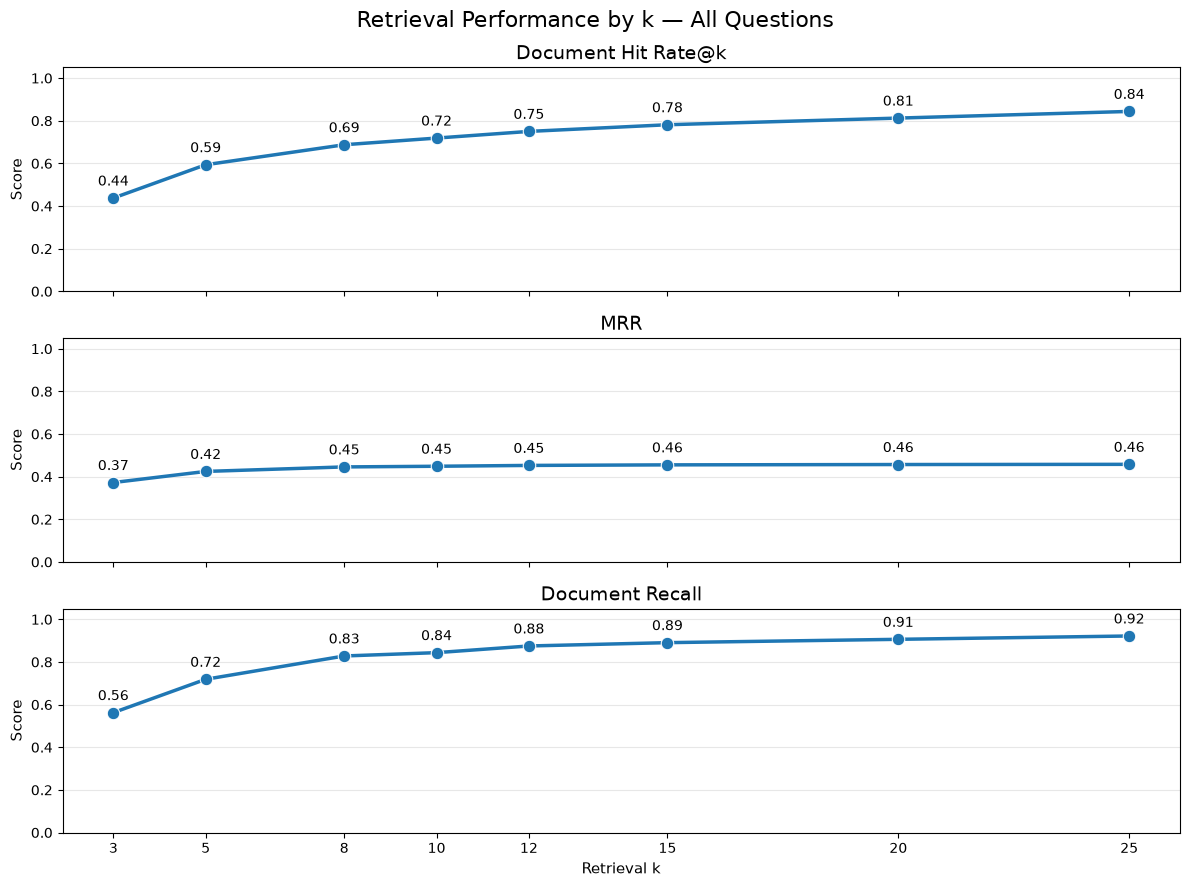

In [23]:
plot_retrieval_metrics(df_k , x_axis="retrieval_k")


### Chunk Size Iteration

In [ ]:
chunk_size = [300,400,500,800,1000,1500,2000, 3000]
for size in tqdm(chunk_size):
    print(f"In progress size:{size}")
    config = run_config(pipeline_version = "v2",retrieval_k= 10, chunk_size=size)
    config_dict = config.get_dictionary()
    try:
        detailed_questions, summary = await evaluate(config_dict, retrieval_only=True)
    except: 
        continue

In [27]:
path  = Path(r"C:\Users\david\Documents\Projects\crypto_chatbot_rag\data\rag_evaluation\results\retrieval\chunk_size_iteration")
df_chunk_size = get_comparisson_df_summary(path)

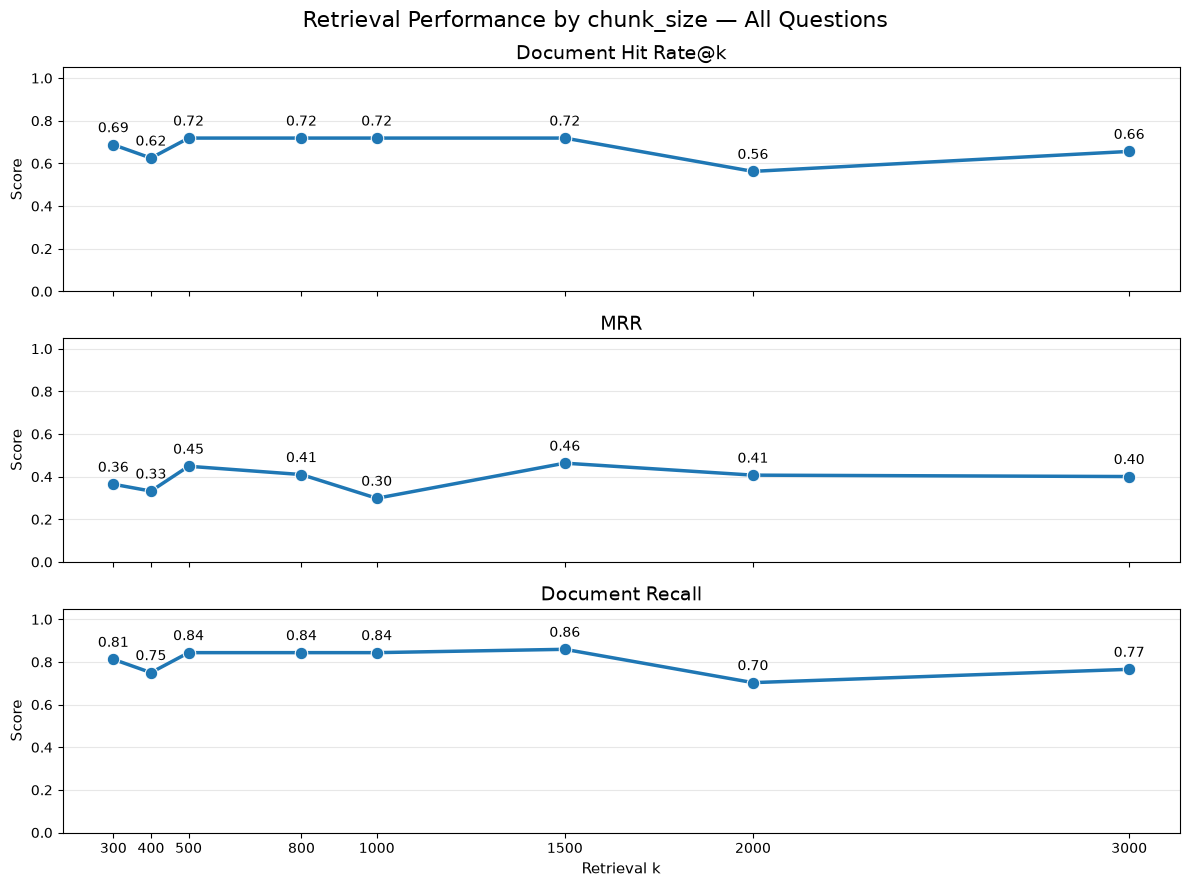

In [26]:
plot_retrieval_metrics(df_chunk_size , x_axis="chunk_size")

### Chunk Overlap Iteration

In [ ]:
chunk_overlap = [50,75,100,120,150,200,300,500]
for overlap in tqdm(chunk_overlap):
    print(f"In progress overlap:{overlap}")
    config = run_config(pipeline_version = "v2",retrieval_k= 10, chunk_size=500, chunk_overlap=overlap)
    config_dict = config.get_dictionary()
    try:
        detailed_questions, summary = await evaluate(config_dict, retrieval_only=True)
    except: 
        continue

In [29]:
path  = Path(r"C:\Users\david\Documents\Projects\crypto_chatbot_rag\data\rag_evaluation\results\retrieval\overlap_iteration")
df_chunk_overlap = get_comparisson_df_summary(path)

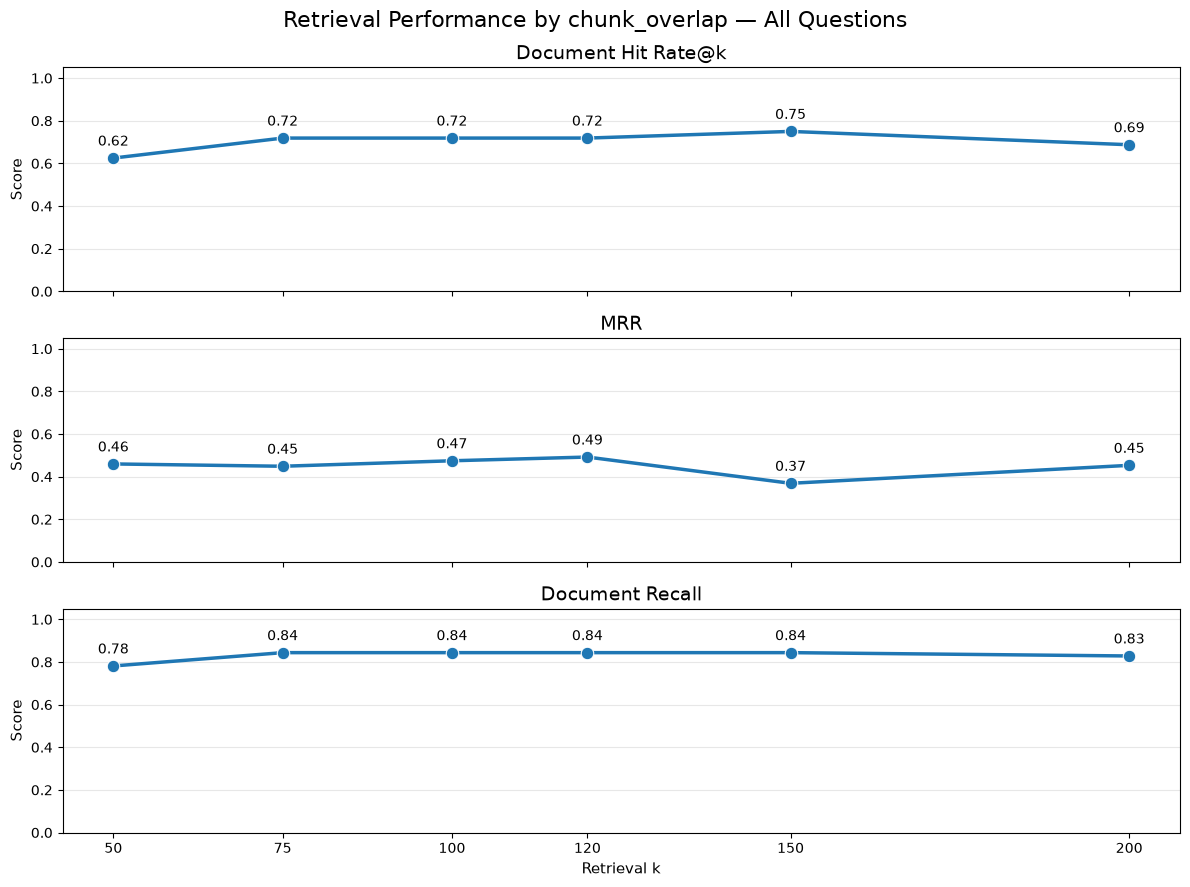

In [30]:
plot_retrieval_metrics(df_chunk_overlap , x_axis="chunk_overlap")

### Embedding Model Iteration


In [ ]:
embedding_models = ["qwen/qwen3-embedding-8b",
                    "google/gemini-embedding-2",
                    "baai/bge-m3",
                    "openai/text-embedding-3-large",
                    "openai/text-embedding-3-small"]

for model in tqdm(embedding_models):
    print(f"In progress iteration -> model:{model}")
    config = run_config(pipeline_version = "v2", retrieval_k= 10, chunk_size=500, chunk_overlap=120, embedding_model=model)
    config_dict = config.get_dictionary()
    try:
        detailed_questions, summary = await evaluate(config_dict, retrieval_only=True)
    except: 
        continue

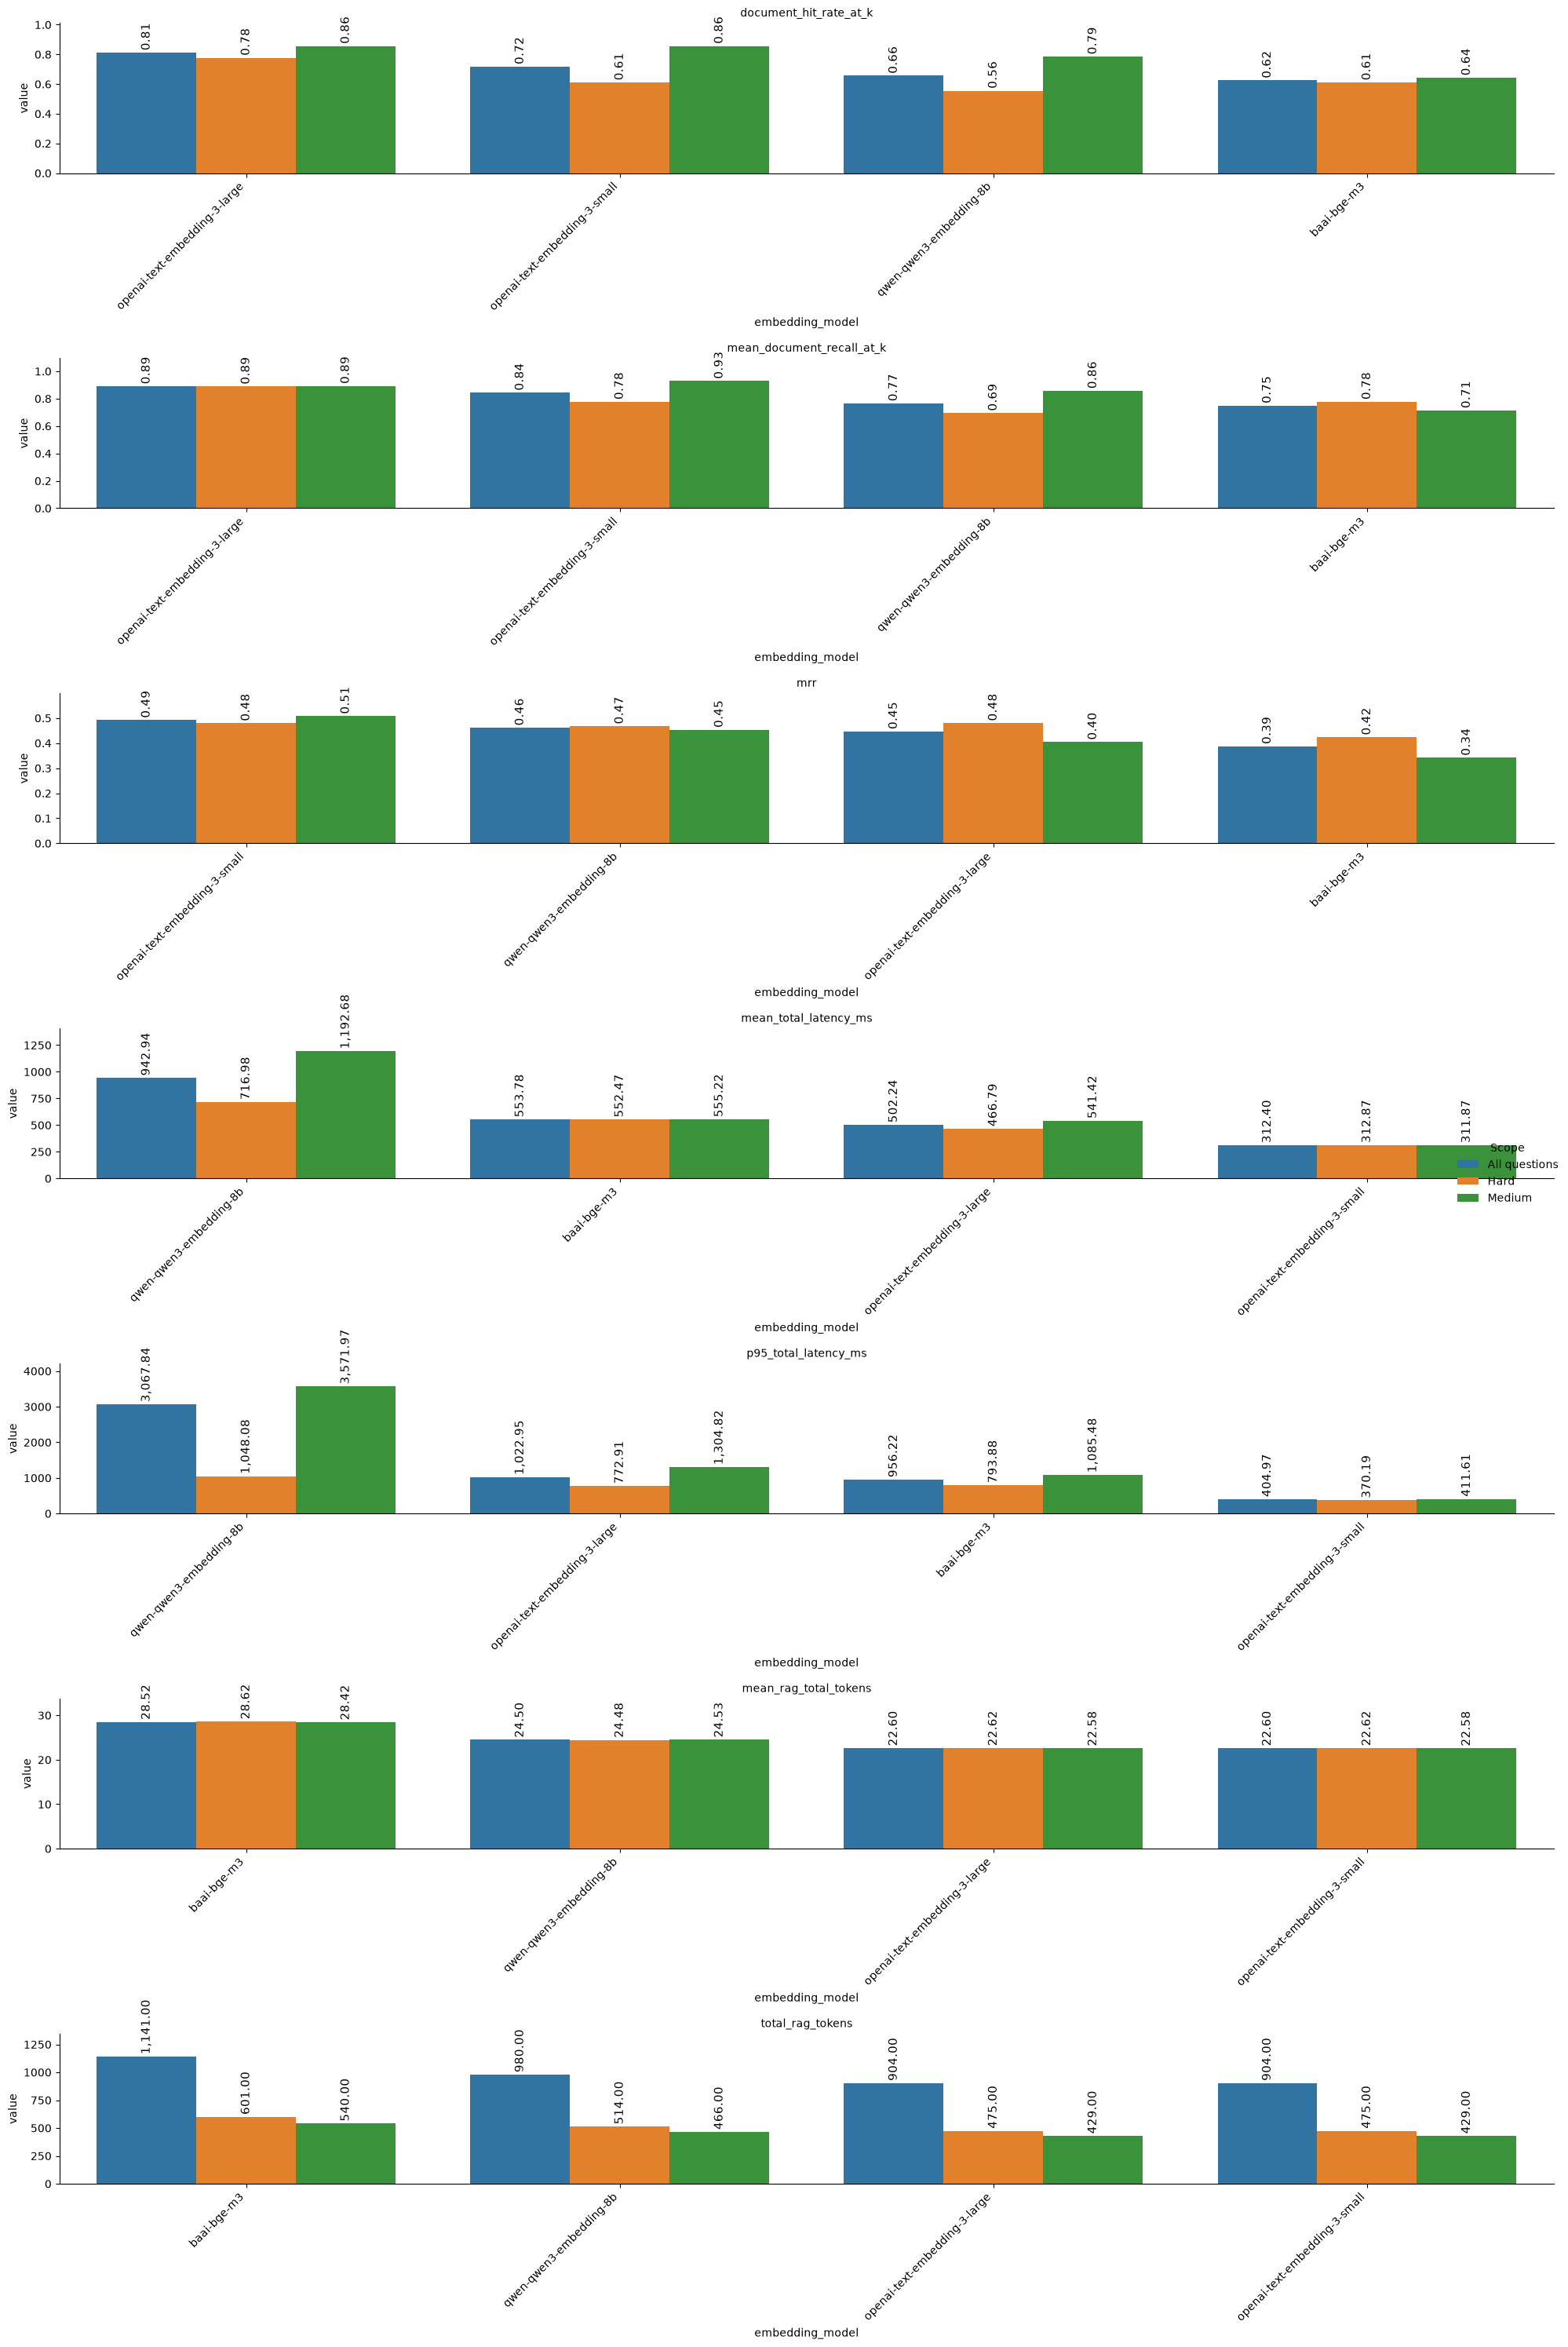

In [33]:
path  = Path(r"C:\Users\david\Documents\Projects\crypto_chatbot_rag\data\rag_evaluation\results\retrieval\embedding_model")
df_embedding_model = get_comparisson_df_summary(path)
get_plots(df_embedding_model , "embedding_model", retrieval_only=True)

## Iterate over the top 3 values for each of the params.

Becasue we dont want to get locked in a specific parameter that we selected at the beginning, we plan to select the top 3 params for each of the previous analysis and iterate over each combination. This also with the intend on improve the metrics, because they got freeze after changing the chunk size and overlap.

In [ ]:
retrieval_k = [10,12,8]
chunk_size = [500,800,1500]
chunk_overlap = [75,100,120]
embedding_models = ["openai/text-embedding-3-large",
                    "openai/text-embedding-3-small"]


for model in tqdm(embedding_models):
    for size in tqdm(chunk_size):
        for overlap in tqdm(chunk_overlap):
            for k in tqdm(retrieval_k):
                print(f"In progress iteration -> model:{model}, chunk_size:{size}, chunk_overlap:{overlap}, retrieval_k:{k}")
                config = run_config(pipeline_version = "v2", retrieval_k= k, chunk_size=size, chunk_overlap=overlap, embedding_model=model)
                config_dict = config.get_dictionary()
                try:
                    detailed_questions, summary = await evaluate(config_dict, retrieval_only=True)
                except: 
                    continue

In [34]:
path  = Path(r"C:\Users\david\Documents\Projects\crypto_chatbot_rag\data\rag_evaluation\results\retrieval\total_iteration")
df_iteration = get_comparisson_df_summary(path)

In [41]:
import plotly.express as px

df_plot = df_iteration[df_iteration['scope']=='All questions'].sort_values("document_hit_rate_at_k")

fig =px.scatter(df_plot,
             x='document_hit_rate_at_k',
             y='mrr',
             hover_data=['mean_document_recall_at_k','retrieval_k','chunk_size','chunk_overlap','embedding_model']
             
)

fig.show()

## Conclusion 

After completing the analysis, two configurations stood out as the best performers across the metrics we evaluated.

Configuration A achieved the highest MRR overall. 

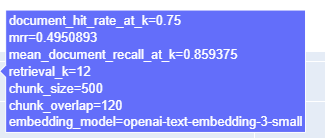

Configuration B, on the other hand, offers a strong balance between hit rate and MRR.

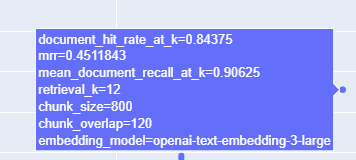

For the next iterations on the generation side, we will move forward with Configuration B. The main reason is that a higher hit rate aligns better with the goals of this project, and the MRR difference between the two configurations is small enough that the tradeoff is worth it.

That said, we are not setting Configuration A aside permanently. Once we reach the end of the full iteration cycle, we will revisit it to confirm whether Configuration B continues to be the stronger choice.

# Generative Phase Iteration

For generation model selection, we focused on the top value-rated models available on OpenRouter, working within a $10 budget. Our goal was to identify the options that offered the best performance at the lowest input and output token cost.

In the first iteration, we evaluated the top 10 models from a range of providers, analyzed the results, and narrowed the list down to the 5 that performed best.

In [ ]:
# We are going to get the baseline run config metrics. 
config = run_config(pipeline_version = "v3", retrieval_k= 12, chunk_size=800, chunk_overlap=120, embedding_model="openai/text-embedding-3-large")
config_dict = config.get_dictionary()
detailed_questions, summary = await evaluate(config_dict, retrieval_only=False)

In [ ]:
generation_models_batch_1 = ["openai/gpt-5.6-luna",
                     "openai/gpt-oss-120b",
                     "qwen/qwen3-32b",
                     "google/gemini-2.5-flash-lite",
                     "x-ai/grok-4.3",
                     "anthropic/claude-haiku-4.5",
                     "upstage/solar-pro4" ]

In [11]:
from RAG_model.evaluation.evaluation import print_progress
from time import perf_counter

model_total = len(generation_models_batch_1)
model_started_at = perf_counter()

for model_number, model in enumerate(generation_models_batch_1, start=1):
    print_progress(
        model_number - 1,
        model_total,
        "Generation models",
        f"Evaluating {model}",
        model_started_at,
    )
    config = run_config(
        pipeline_version="v3",
        retrieval_k=12,
        chunk_size=800,
        chunk_overlap=120,
        embedding_model="openai/text-embedding-3-large",
        generation_model=model,
    )

    try:
        detailed_questions, summary = await evaluate(
            config.get_dictionary(),
            retrieval_only=False,
        )
    except Exception as error:
        print(
            f"Evaluation failed for {model}: {type(error).__name__}: {error}",
            flush=True,
        )

print_progress(
    model_total,
    model_total,
    "Generation models",
    "Complete",
    model_started_at,
)

Questions [deepseek/deepseek-v4-flash-0731]:   8%|#2               | 3/40 [04:59<1:01:30, 99.73s/it] | Evaluating Q4: In IBIT's Q1 2025 filing, where do the shares trade, which benchmark is used ...
Evaluation failed for deepseek/deepseek-v4-flash-0731: RuntimeError: Evaluation failed for question 4: Generation model returned no text. finish_reason=length
Generation models: 100%|#############################################| 1/1 [06:33<00:00, 393.74s/it] | Complete


In [ ]:
path = Path(r"C:\Users\david\Documents\Projects\crypto_chatbot_rag\data\rag_evaluation\results\Generation")
df_gen_model = get_comparisson_df_summary(path) 
get_plots(df_gen_model , "generation_model", retrieval_only=False)

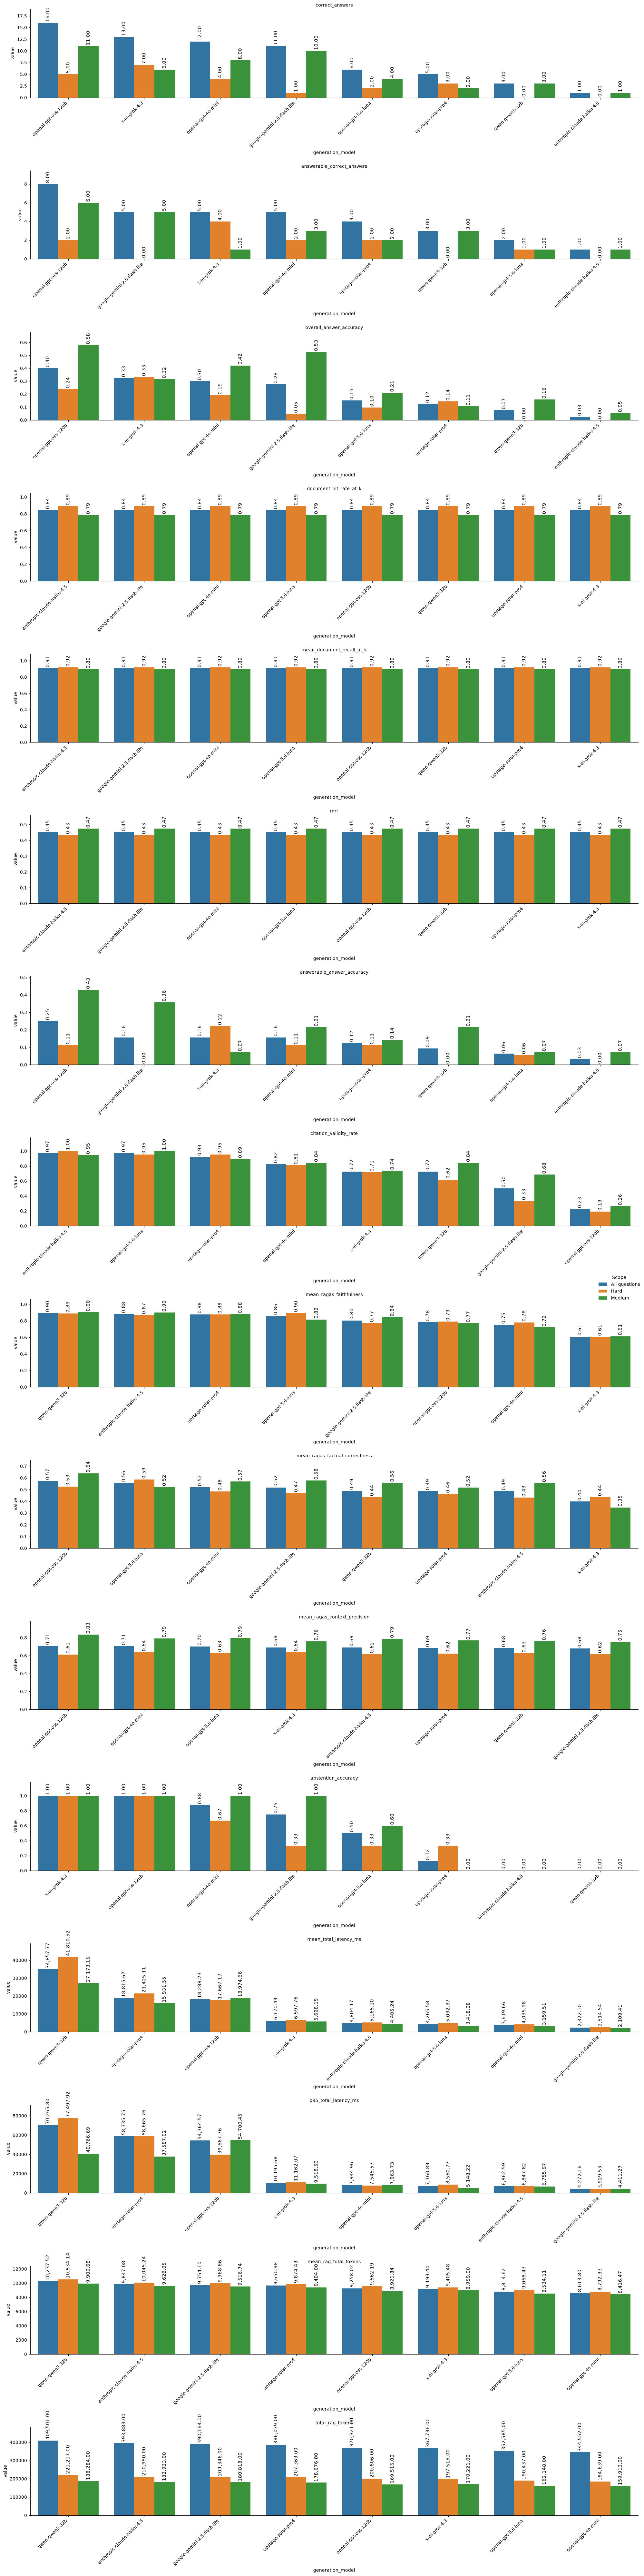

In [47]:
get_plots(df_gen_model , "generation_model", retrieval_only=False)

We are going to select gpt-oss-120b and gpt-luna 5.6 from Open Ai as the 2 models that we are going to keep iterating  to improve the results

# GPT OSS

In [49]:
df_gpt_oss = pd.read_csv(r"C:\Users\david\Documents\Projects\crypto_chatbot_rag\data\rag_evaluation\results\Generation\chunk-800__overlap-120__embedding-openai-text-embedding-3-large__k-12__generator-openai-gpt-oss-120b__prompt-v1\question_results.csv")

In [74]:
df_gpt_oss.columns

Index(['question_id', 'category', 'difficulty', 'answerable',
       'expected_documents', 'document_hit_at_k', 'document_recall_at_k',
       'reciprocal_rank', 'retrieved_chunk_ids', 'retrieved_accession_numbers',
       'retrieved_ranked_documents', 'similarity_scores', 'citations_valid',
       'abstention_correct', 'retrieval_latency_ms', 'generation_latency_ms',
       'total_latency_ms', 'ragas_answer_correct', 'ragas_faithfulness',
       'ragas_factual_correctness', 'ragas_context_precision',
       'embedding_tokens', 'generation_input_tokens',
       'generation_output_tokens', 'rag_total_tokens'],
      dtype='object')

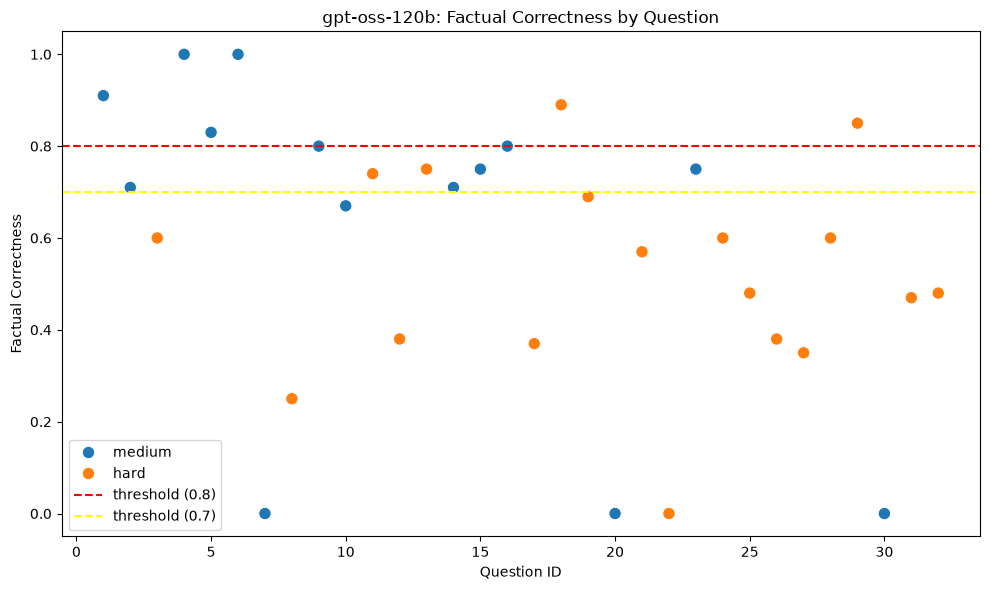

In [59]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_gpt_oss,
    x='question_id',
    y='ragas_factual_correctness',
    hue='difficulty', 
    ax=ax,
    s=80
)

ax.axhline(y=0.8, color='red', linestyle='--', label='threshold (0.8)')
ax.axhline(y=0.7, color='yellow', linestyle='--', label='threshold (0.7)')

ax.set_xlabel('Question ID')
ax.set_ylabel('Factual Correctness')
ax.set_title('gpt-oss-120b: Factual Correctness by Question')
ax.legend()

plt.tight_layout()
plt.show()

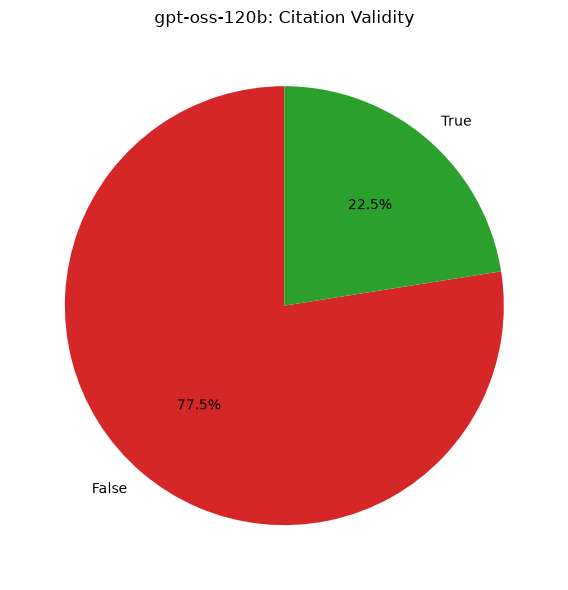

In [73]:
fig, ax = plt.subplots(figsize=(6, 6))

counts = df_gpt_oss['citations_valid'].value_counts().reindex([False, True], fill_value=0)

ax.pie(
    counts,
    labels=['False', 'True'],
    autopct='%1.1f%%',
    colors=['#d62728', '#2ca02c'],
    startangle=90
)
ax.set_title('gpt-oss-120b: Citation Validity')
plt.tight_layout()
plt.show()

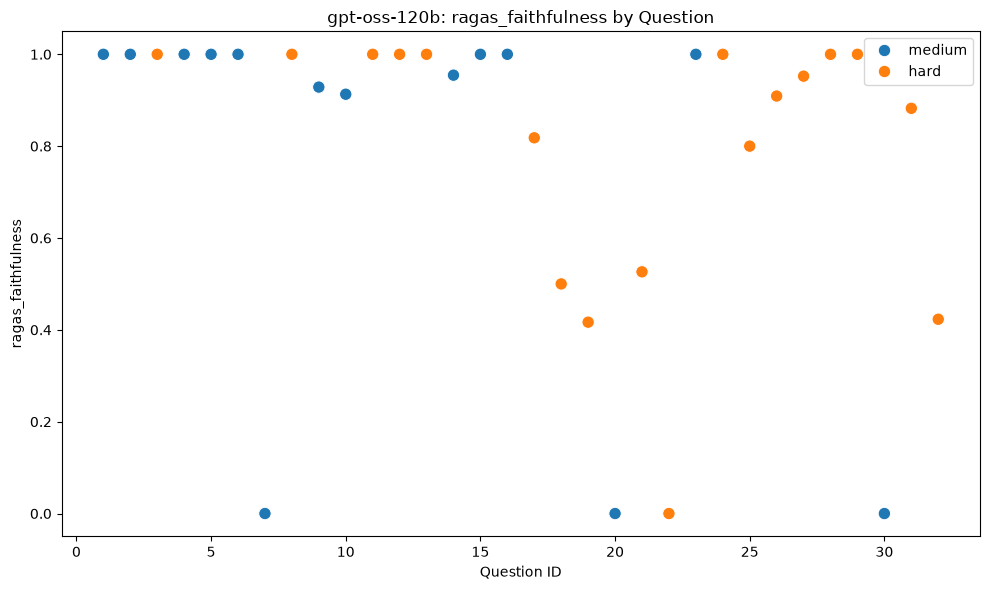

In [82]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_gpt_oss,
    x='question_id',
    y='ragas_faithfulness',
    hue='difficulty', 
    ax=ax,
    s=80
)


ax.set_xlabel('Question ID')
ax.set_ylabel('ragas_faithfulness')
ax.set_title('gpt-oss-120b: ragas_faithfulness by Question')
ax.legend()

plt.tight_layout()
plt.show()

## Lets try with the second configuration we found from retrieval
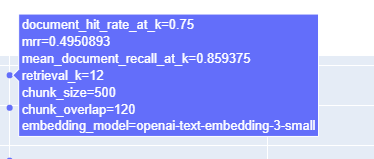


In [20]:
config = run_config(
        pipeline_version="v3",
        retrieval_k=12,
        chunk_size=500,
        chunk_overlap=120,
        embedding_model="openai/text-embedding-3-small",
        generation_model="openai/gpt-oss-120b",
    )


detailed_questions, summary = await evaluate(
    config.get_dictionary(),
    retrieval_only=False,
)


Parquet file already exists.
Collection already created.
Questions [openai/gpt-oss-120b]: 100%|##############################| 40/40 [27:58<00:00, 41.97s/it] | Complete


In [7]:
df_gpt_new = pd.read_csv(r'C:\Users\david\Documents\Projects\crypto_chatbot_rag\data\rag_evaluation\results\chunk-800__overlap-120__embedding-openai-text-embedding-3-small__k-12__generator-openai-gpt-oss-120b__prompt-v1\question_results.csv')

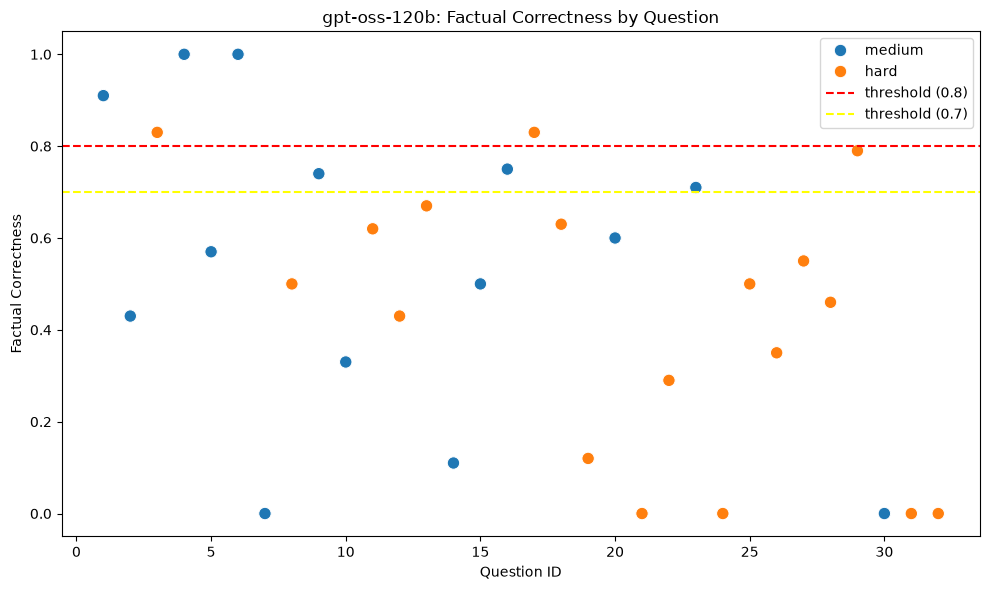

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_gpt_new,
    x='question_id',
    y='ragas_factual_correctness',
    hue='difficulty', 
    ax=ax,
    s=80
)

ax.axhline(y=0.8, color='red', linestyle='--', label='threshold (0.8)')
ax.axhline(y=0.7, color='yellow', linestyle='--', label='threshold (0.7)')

ax.set_xlabel('Question ID')
ax.set_ylabel('Factual Correctness')
ax.set_title('gpt-oss-120b: Factual Correctness by Question')
ax.legend()

plt.tight_layout()
plt.show()

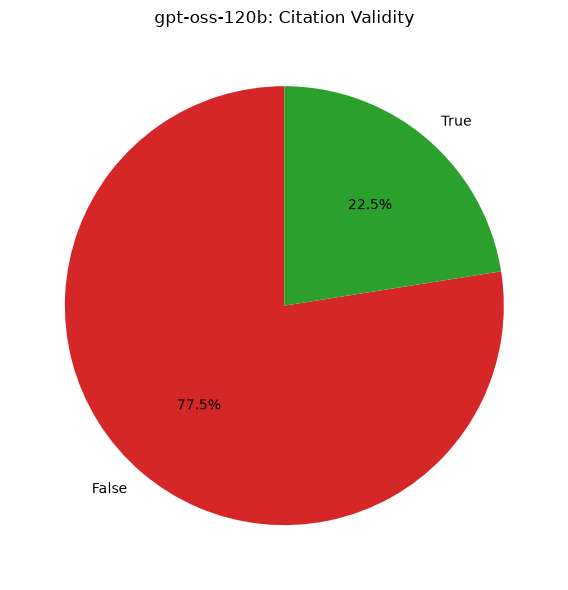

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

counts = df_gpt_new['citations_valid'].value_counts().reindex([False, True], fill_value=0)

ax.pie(
    counts,
    labels=['False', 'True'],
    autopct='%1.1f%%',
    colors=['#d62728', '#2ca02c'],
    startangle=90
)
ax.set_title('gpt-oss-120b: Citation Validity')
plt.tight_layout()
plt.show()

 No Improvement from the other configuration for retrieval, it even got worst accuracy 

# GPT 5.6 Luna

In [83]:
df_gpt_luna = pd.read_csv(r"C:\Users\david\Documents\Projects\crypto_chatbot_rag\data\rag_evaluation\results\Generation\chunk-800__overlap-120__embedding-openai-text-embedding-3-large__k-12__generator-openai-gpt-5.6-luna__prompt-v1\question_results.csv")

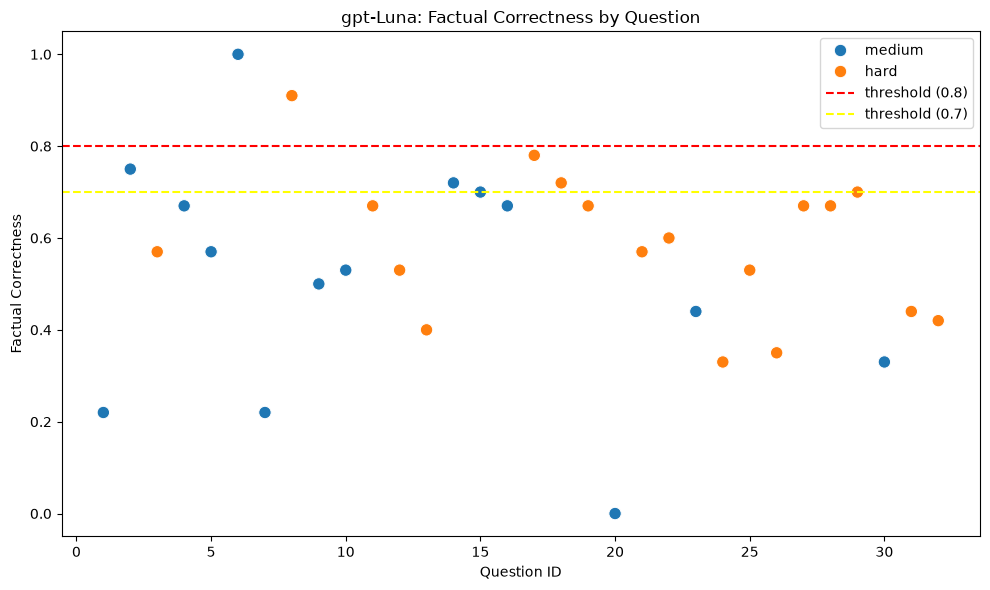

In [87]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_gpt_luna,
    x='question_id',
    y='ragas_factual_correctness',
    hue='difficulty', 
    ax=ax,
    s=80
)

ax.axhline(y=0.8, color='red', linestyle='--', label='threshold (0.8)')
ax.axhline(y=0.7, color='yellow', linestyle='--', label='threshold (0.7)')

ax.set_xlabel('Question ID')
ax.set_ylabel('Factual Correctness')
ax.set_title('gpt-Luna: Factual Correctness by Question')
ax.legend()

plt.tight_layout()
plt.show()

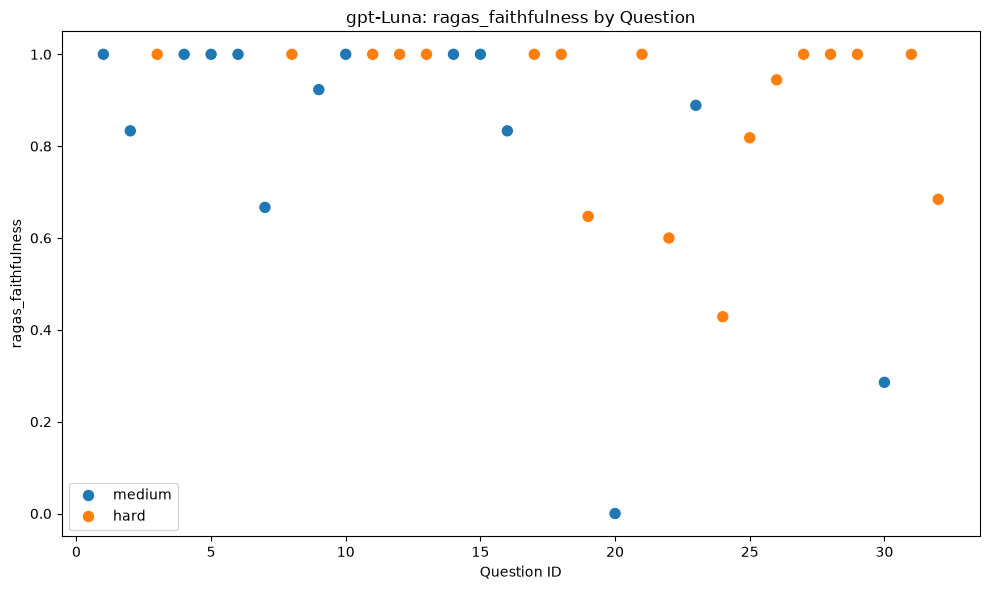

In [88]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_gpt_luna,
    x='question_id',
    y='ragas_faithfulness',
    hue='difficulty', 
    ax=ax,
    s=80
)


ax.set_xlabel('Question ID')
ax.set_ylabel('ragas_faithfulness')
ax.set_title('gpt-Luna: ragas_faithfulness by Question')
ax.legend()

plt.tight_layout()
plt.show()

## Try with the other configuration too with this model


In [ ]:
config_luna = run_config(
        pipeline_version="v4",
        prompt_version="v2",
        retrieval_k=12,
        chunk_size=500,
        chunk_overlap=120,
        embedding_model="openai/text-embedding-3-small",
        generation_model="openai/gpt-5.6-luna",
    )



In [8]:
detailed_questions, summary = await evaluate(
    config_luna.get_dictionary(),
    retrieval_only=False,
)

Parquet file already exists.
Collection already created.
Questions [openai/gpt-5.6-luna]: 100%|##############################| 40/40 [32:36<00:00, 48.91s/it] | Complete


In [11]:
df_luna_new = pd.read_csv(r"C:\Users\david\Documents\Projects\crypto_chatbot_rag\data\rag_evaluation\results\chunk-800__overlap-120__embedding-openai-text-embedding-3-small__k-12__generator-openai-gpt-5.6-luna__prompt-v1\question_results.csv")

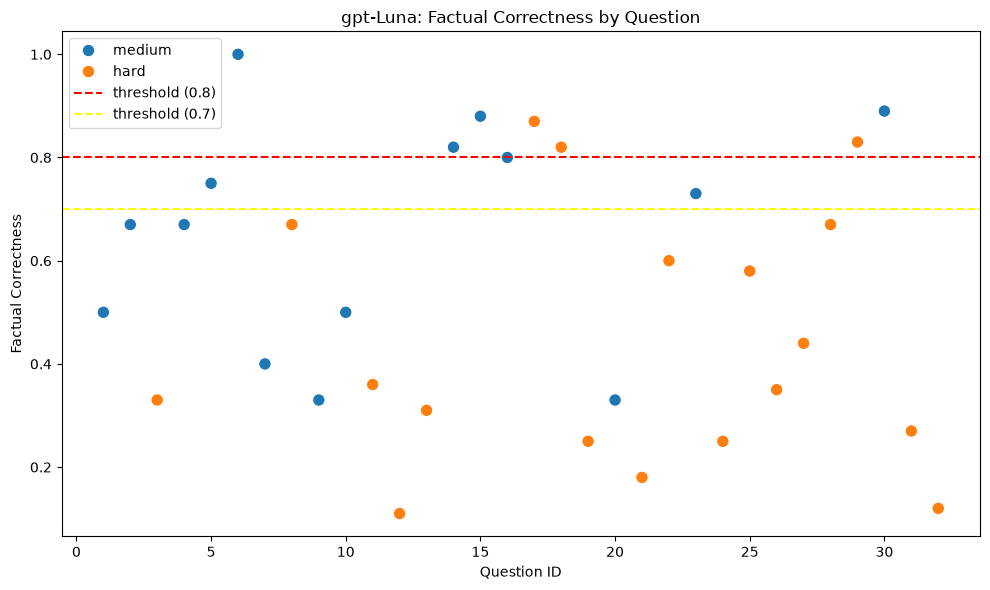

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_luna_new,
    x='question_id',
    y='ragas_factual_correctness',
    hue='difficulty', 
    ax=ax,
    s=80
)

ax.axhline(y=0.8, color='red', linestyle='--', label='threshold (0.8)')
ax.axhline(y=0.7, color='yellow', linestyle='--', label='threshold (0.7)')

ax.set_xlabel('Question ID')
ax.set_ylabel('Factual Correctness')
ax.set_title('gpt-Luna: Factual Correctness by Question')
ax.legend()

plt.tight_layout()
plt.show()

We have found that the configuration A, has a a better results with the gpt Luna. We will comapre both configuration and try to improve the accuracy that keeps beign really bad.

# Comparison for Luna LLM with different prompt versions

Because the generation step is not deterministic, we have todo multiple iterations over different types of prompts, so we can have a mean value answers correct and other metrics. We will run a loop of running the evlauation 5 times per each prompt version and then we can select the best type of prompts.

In [15]:
prompts = {
    "v1": """ You answer only with information from supplied SEC 10-K and 10-Q filing extracts.
The corpus covers IBIT, ETHA, FBTC, FETH, GBTC, and ETHE. If the corpus does not contain enough information, say: "I could not find enough evidence in the retrieved SEC filings."
Answer using only the supplied context. Cite every factual claim using supplied IDs in this format: [SOURCE: source-id]. Never invent a source ID. Do not infer, calculate, or compare values unless the retrieved context contains all evidence needed.
If the retrieved context does not clearly support an answer, abstain rather than guess.
Do not fill missing information with assumptions or outside knowledge.""",

"v2":""" You are an assistant that answers questions about these tickers only: 
IBIT, ETHA, FBTC, FETH, GBTC, and ETHE, using 10-K and 10-Q SEC filings only.

Follow these steps in order:

1. Find evidence
Identify the specific passage(s) in the retrieved context that answer the 
user's question. If you cannot identify sufficient evidence, go to Step 4.

2. Check sufficiency
- The context must contain ALL facts needed to answer the question.
- For comparisons, every value being compared must be explicitly present.
- For calculations, every required input must be explicitly present.
- If any required information is missing, go to Step 4.

3. Answer
Write a clear, complete, professional answer in your own words, based only 
on the passages you identified. You may paraphrase and connect related 
facts into a coherent answer, but every fact, number, or claim must come 
directly from those passages — do not add anything they don't state. 
Cite each distinct factual claim once, using its source ID in this format: 
[SOURCE: source-id]. Never invent or modify a source ID.

4. Abstain
Respond with exactly:
"I could not find enough evidence in the retrieved SEC filings."

Examples:

Question: "What was IBIT's total expense ratio disclosed in its most 
recent 10-K?"
Context: [IBIT's 10-K states an expense ratio of 0.25%.]
Answer: "IBIT's expense ratio, as disclosed in its most recent 10-K, is 
0.25% [SOURCE: source-id]."
(Correct: single fact, directly stated, cited once.)

Question: "How did IBIT's AUM compare to FBTC's in Q2?"
Context: [IBIT's Q2 AUM is present, but FBTC's Q2 AUM is missing.]
Answer: "I could not find enough evidence in the retrieved SEC filings."
(Correct: one of the two values needed for the comparison is missing.)
""",

"v3":""" You are an assistant that answers questions about these tickers only: IBIT, ETHA, FBTC, FETH, GBTC, and ETHE, using 10-K and 10-Q SEC filings only.
Follow these steps in order:

Find evidence Identify the specific passage(s) in the retrieved context that answer the user's question. If you cannot identify sufficient evidence, go to Step 4.
Check sufficiency

The context must contain ALL facts needed to answer the question.
For comparisons, every value being compared must be explicitly present.
For calculations, every required input must be explicitly present.
Do not use outside knowledge, assumptions, inference, or estimation.
If any required information is missing, go to Step 4.

Answer Using only the identified passages, provide a clear, professional answer. Cite every factual claim using its source ID in this format: [SOURCE: source-id]. Never invent or modify a source ID.
Abstain Respond with exactly:
"I could not find enough evidence in the retrieved SEC filings."
Example:
Question: "How did IBIT's AUM compare to FBTC's in Q2?"
Context: [IBIT's Q2 AUM is present, but FBTC's Q2 AUM is missing.]
Answer:
"I could not find enough evidence in the retrieved SEC filings."""
}

In [ ]:
for i in tqdm(range(3), desc="Iterations"):
    for version, prompt in tqdm(
        prompts.items(),
        desc=f"Prompts {i + 1}/5",
        leave=False
    ):
        
        config_luna = run_config(
            pipeline_version="v4",
            prompt_version=f"{version}_{i + 1}",
            retrieval_k=12,
            chunk_size=500,
            chunk_overlap=120,
            embedding_model="openai/text-embedding-3-small",
            generation_model="openai/gpt-5.6-luna",
        )

        detailed_questions, summary = await evaluate(
            config_luna.get_dictionary(),
            prompt,
            retrieval_only=False,
        )

Iterations:   0%|          | 0/3 [00:00<?, ?it/s]

Questions [openai/gpt-5.6-luna]: 100%|##############################| 40/40 [24:24<00:00, 36.61s/it] | Complete


Questions [openai/gpt-5.6-luna]: 100%|##############################| 40/40 [24:51<00:00, 37.30s/it] | Complete


Questions [openai/gpt-5.6-luna]: 100%|##############################| 40/40 [23:35<00:00, 35.39s/it] | Complete


Iterations:  33%|███▎      | 1/3 [1:16:10<2:32:21, 4570.63s/it]

Questions [openai/gpt-5.6-luna]:  78%|#######################2      | 31/40 [23:05<06:42, 44.70s/it] | Evaluating Q32: Summarize the main operational differences between BlackRock's ETHA and Fidel...


In [9]:
path = Path(r"C:\Users\david\Documents\Projects\crypto_chatbot_rag\data\rag_evaluation\results\configurations_test")
df_comparison = get_comparisson_df_summary(path) 
df_comparison['id'] = df_comparison['generation_model']+"_"+df_comparison['prompt_version']

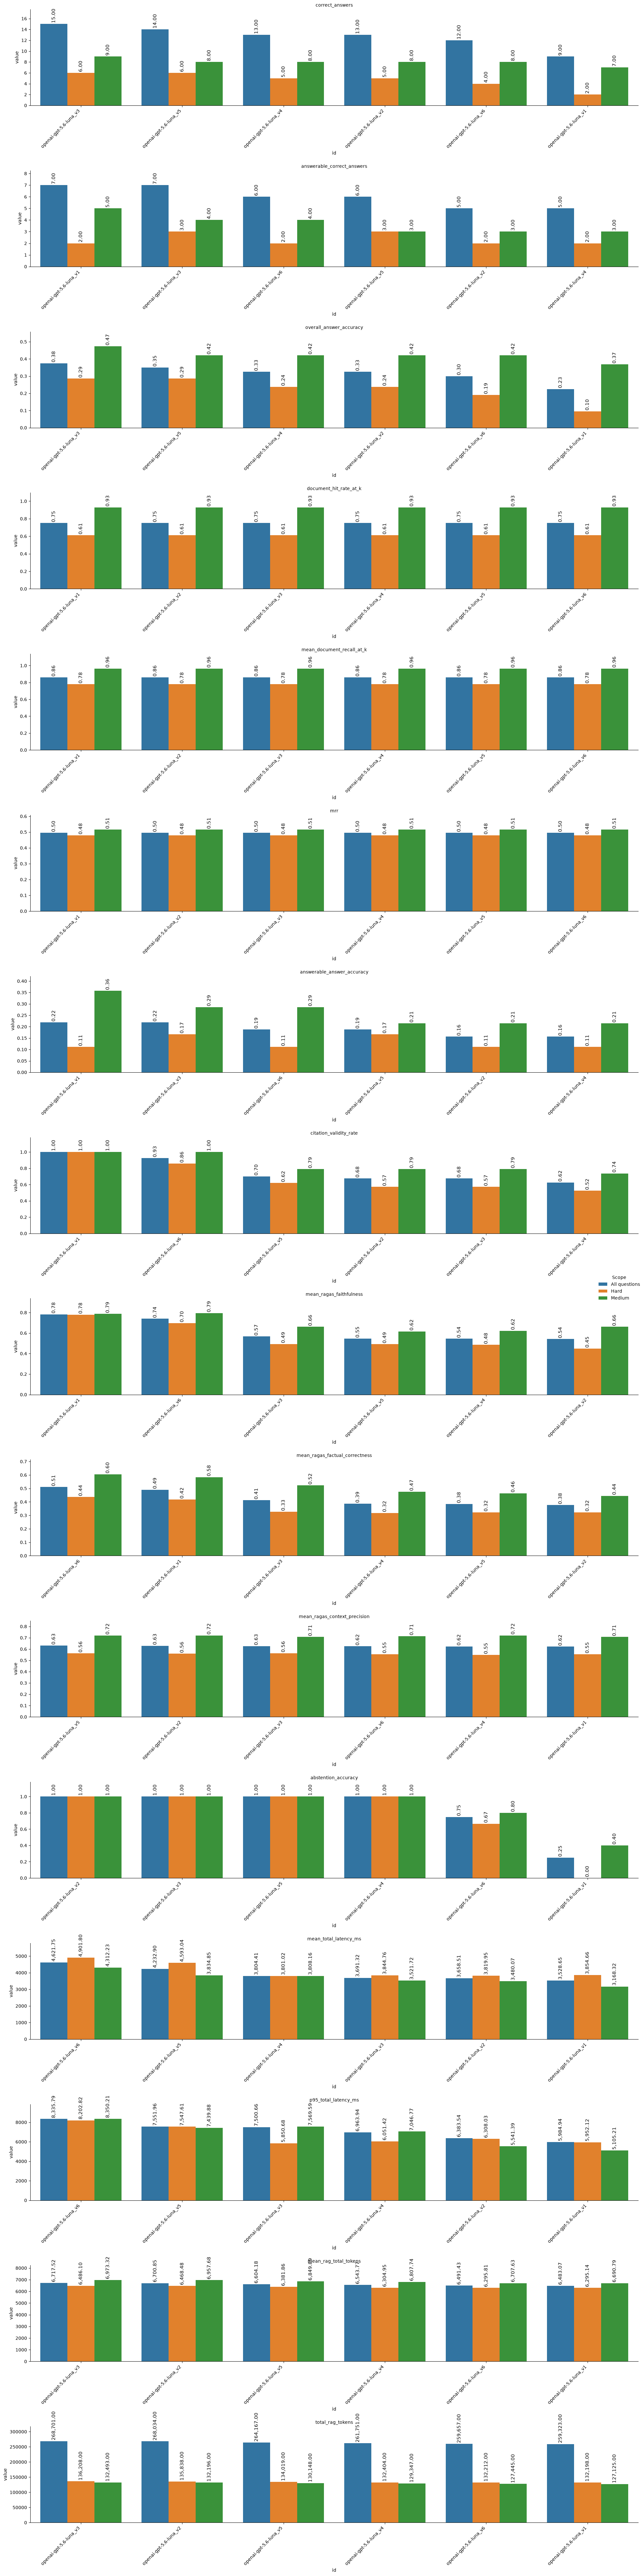

In [10]:
get_plots(df_comparison , "id", retrieval_only=False)

We are going to stay with prompt 2. The modificatiosn from prompt 3 wher really small, and we didnt get the best result we where expecting, so maybe we got into a plateau into the prompt side